# PRDA – 04 Job Market Analysis
# Internship Project

In [1]:
!pip install pandas numpy matplotlib seaborn sqlalchemy pymysql openpyxl plotly


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import pymysql
import openpyxl
import plotly
import os
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Create folders automatically

In [3]:
folders = [
    "data",
    "data/raw",
    "data/processed",
    "outputs",
    "outputs/charts",
    "outputs/tables",
    "outputs/reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All project folders created successfully.")

All project folders created successfully.


## Database credentials

In [4]:
DB_HOST = "YOUR_HOST"
DB_PORT = 3306
DB_NAME = "YOUR_DB_NAME"
DB_USER = "YOUR_USERNAME"
DB_PASSWORD = "YOUR_PASSWORD"
DB_TABLE = "YOUR_TABLE_NAME"

## Fetch data from database

In [5]:
try:
    connection = pymysql.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )

    query = f"SELECT * FROM {DB_TABLE};"
    df = pd.read_sql(query, connection)

    print("Database connected successfully.")
    print("Dataset shape:", df.shape)

except Exception as e:
    print("Database connection failed.")
    print("Error:", e)

Database connected successfully.
Dataset shape: (742, 42)


## View first rows

df.head()

## Save raw data

In [6]:
df.to_csv("data/raw/job_data_raw.csv", index=False)
print("Raw data saved successfully.")

Raw data saved successfully.


## Shape

In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (742, 42)


## Column names

In [8]:
print(df.columns.tolist())

['ID', 'Job_Title', 'Salary_Estimate', 'FIELD4', 'Rating', 'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Hourly', 'Employer_provided', 'Lower_Salary', 'Upper_Salary', 'Avg_SalaryK', 'company_txt', 'Job_Location', 'Age', 'Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'Degree']


## Info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  742 non-null    int64  
 1   Job_Title           742 non-null    object 
 2   Salary_Estimate     742 non-null    object 
 3   FIELD4              0 non-null      object 
 4   Rating              742 non-null    float64
 5   Company_Name        742 non-null    object 
 6   Location            742 non-null    object 
 7   Headquarters        742 non-null    object 
 8   Size                742 non-null    object 
 9   Founded             742 non-null    int64  
 10  Type_of_ownership   742 non-null    object 
 11  Industry            742 non-null    object 
 12  Sector              742 non-null    object 
 13  Revenue             742 non-null    object 
 14  Competitors         742 non-null    object 
 15  Hourly              742 non-null    object 
 16  Employer

## Missing values

In [10]:
df.isnull().sum()

ID                      0
Job_Title               0
Salary_Estimate         0
FIELD4                742
Rating                  0
Company_Name            0
Location                0
Headquarters            0
Size                    0
Founded                 0
Type_of_ownership       0
Industry                0
Sector                  0
Revenue                 0
Competitors             0
Hourly                  0
Employer_provided       0
Lower_Salary            0
Upper_Salary            0
Avg_SalaryK             0
company_txt             0
Job_Location            0
Age                     0
Python                  0
spark                   0
aws                     0
excel                   0
sql_                    0
sas                     0
keras                   0
pytorch                 0
scikit                  0
tensor                  0
hadoop                  0
tableau                 0
bi                      0
flink                   0
mongo                   0
google_an   

## Replace -1 with NaN

In [11]:
df = df.replace(-1, np.nan)
df = df.replace("-1", np.nan)

print("Replaced -1 values with NaN.")

Replaced -1 values with NaN.


## Clean column names

In [12]:
df.columns = [col.strip().replace(" ", "_").replace(".", "").replace("-", "_").replace("(", "").replace(")", "") for col in df.columns]
print(df.columns.tolist())

['ID', 'Job_Title', 'Salary_Estimate', 'FIELD4', 'Rating', 'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Hourly', 'Employer_provided', 'Lower_Salary', 'Upper_Salary', 'Avg_SalaryK', 'company_txt', 'Job_Location', 'Age', 'Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'Degree']


## Rename columns

In [13]:
rename_dict = {}

for col in df.columns:
    col_lower = col.lower()

    if col_lower == "job_title":
        rename_dict[col] = "Job_Title"
    elif col_lower == "salary_estimate":
        rename_dict[col] = "Salary_Estimate"
    elif col_lower == "job_description":
        rename_dict[col] = "Job_Description"
    elif col_lower == "rating":
        rename_dict[col] = "Rating"
    elif col_lower == "company_name":
        rename_dict[col] = "Company_Name"
    elif col_lower == "location":
        rename_dict[col] = "Location"
    elif col_lower == "headquarters":
        rename_dict[col] = "Headquarters"
    elif col_lower == "size":
        rename_dict[col] = "Size"
    elif col_lower == "founded":
        rename_dict[col] = "Founded"
    elif col_lower == "type_of_ownership":
        rename_dict[col] = "Type_of_ownership"
    elif col_lower == "industry":
        rename_dict[col] = "Industry"
    elif col_lower == "sector":
        rename_dict[col] = "Sector"
    elif col_lower == "revenue":
        rename_dict[col] = "Revenue"
    elif col_lower == "competitors":
        rename_dict[col] = "Competitors"
    elif col_lower == "hourly":
        rename_dict[col] = "Hourly"
    elif col_lower == "employer_provided":
        rename_dict[col] = "Employer_provided"
    elif col_lower == "lower_salary":
        rename_dict[col] = "Lower_Salary"
    elif col_lower == "uppr_salary":
        rename_dict[col] = "Uppr_Salary"
    elif col_lower in ["avg_salaryk", "avg_salary_k"]:
        rename_dict[col] = "Avg_Salary_K"
    elif col_lower == "company_txt":
        rename_dict[col] = "company_txt"
    elif col_lower == "jobtitle_sim":
        rename_dict[col] = "Jobtitle_sim"
    elif col_lower == "seniority_by_title":
        rename_dict[col] = "seniority_by_title"
    elif col_lower == "degree":
        rename_dict[col] = "Degree"

df.rename(columns=rename_dict, inplace=True)

print("Columns renamed successfully.")
print(df.columns.tolist())

Columns renamed successfully.
['ID', 'Job_Title', 'Salary_Estimate', 'FIELD4', 'Rating', 'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Hourly', 'Employer_provided', 'Lower_Salary', 'Upper_Salary', 'Avg_Salary_K', 'company_txt', 'Job_Location', 'Age', 'Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'Degree']


## Clean company name

In [14]:
if "Company_Name" in df.columns:
    df["Company_Name"] = df["Company_Name"].astype(str).str.split("\n").str[0].str.strip()

df.head()

,ID,Job_Title,Salary_Estimate,FIELD4,Rating,Company_Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),None,3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 - 1000,1973.0,...,b'\x00',b'\x00',b'\x01',b'\x01',b'\x00',b'\x00',b'\x00',data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),None,3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+,1984.0,...,b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),None,4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 - 1000,2010.0,...,b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),None,3.8,PNNL,"Richland, WA","Richland, WA",1001 - 5000,1965.0,...,b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),None,2.9,Affinity Solutions,"New York, NY","New York, NY",51 - 200,1998.0,...,b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',data scientist,na,na


## Extract state

In [15]:
if "Location" in df.columns:
    df["State"] = df["Location"].astype(str).apply(lambda x: x.split(",")[-1].strip() if "," in x else np.nan)

df[["Location", "State"]].head()

,Location,State
0,"Albuquerque, NM",NM
1,"Linthicum, MD",MD
2,"Clearwater, FL",FL
3,"Richland, WA",WA
4,"New York, NY",NY


## Fill missing values

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

Missing values handled.


## Final missing values check

In [17]:
df.isnull().sum()

ID                      0
Job_Title               0
Salary_Estimate         0
FIELD4                742
Rating                  0
Company_Name            0
Location                0
Headquarters            0
Size                    0
Founded                 0
Type_of_ownership       0
Industry                0
Sector                  0
Revenue                 0
Competitors             0
Hourly                  0
Employer_provided       0
Lower_Salary            0
Upper_Salary            0
Avg_Salary_K            0
company_txt             0
Job_Location            0
Age                     0
Python                  0
spark                   0
aws                     0
excel                   0
sql_                    0
sas                     0
keras                   0
pytorch                 0
scikit                  0
tensor                  0
hadoop                  0
tableau                 0
bi                      0
flink                   0
mongo                   0
google_an   

## Save cleaned data

In [18]:
df.to_csv("data/processed/job_data_cleaned.csv", index=False)
print("Cleaned data saved successfully.")

Cleaned data saved successfully.


## States with most jobs

In [19]:
states_jobs = df["State"].value_counts().reset_index()
states_jobs.columns = ["State", "Job_Count"]
states_jobs

,State,Job_Count
0,CA,152
1,MA,103
2,NY,72
3,VA,41
4,IL,40
5,MD,35
6,PA,33
7,TX,28
8,NC,21
9,WA,21


## Chart

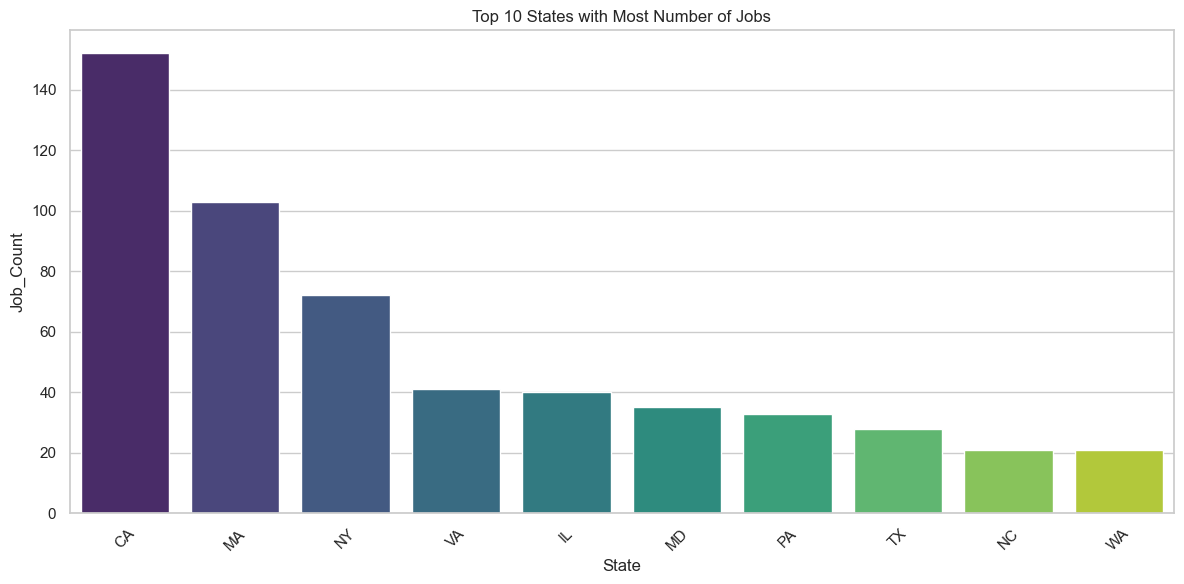

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(data=states_jobs.head(10), x="State", y="Job_Count", palette="viridis")
plt.title("Top 10 States with Most Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/states_with_most_jobs.png")
plt.show()

## Avg min and max salary by state

In [21]:
avg_min_max_salary_state = df.groupby("State")[["Lower_Salary", "Upper_Salary"]].mean().reset_index()
avg_min_max_salary_state = avg_min_max_salary_state.sort_values(by="Lower_Salary", ascending=False)
avg_min_max_salary_state

,State,Lower_Salary,Upper_Salary
2,CA,92.427632,154.598684
5,DC,88.636364,131.727273
11,IL,88.350000,144.975000
16,MA,78.689320,136.300971
18,MI,77.000000,123.500000
23,NJ,76.823529,132.294118
29,RI,74.000000,126.000000
25,NY,72.125000,125.180556
35,WA,71.047619,115.333333
34,VA,70.024390,121.219512


## Chart

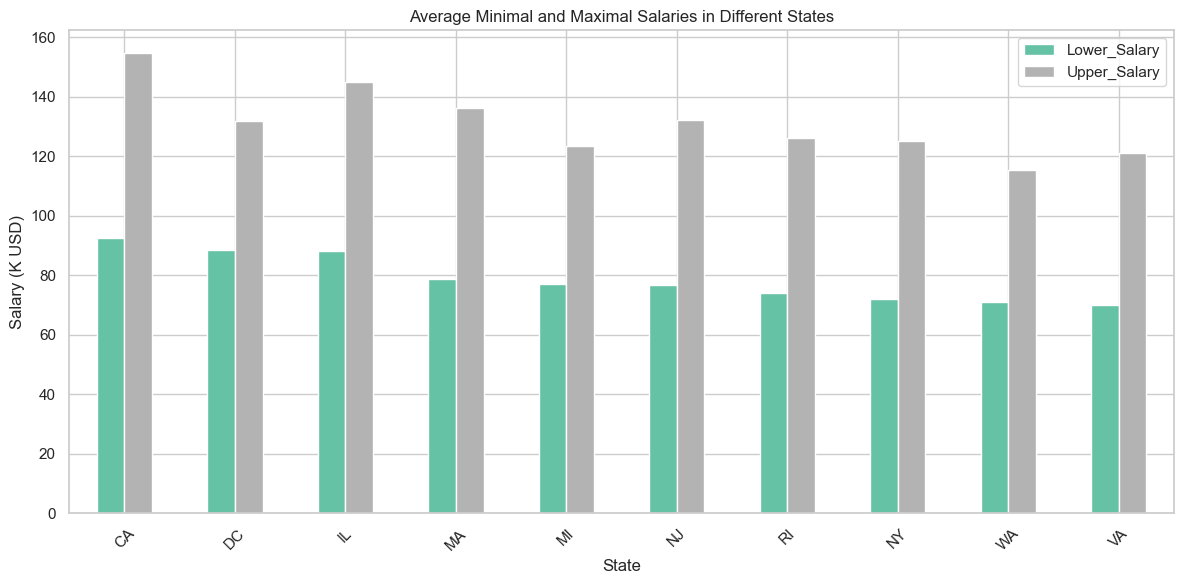

In [22]:
avg_min_max_salary_state.head(10).plot(
    x="State",
    y=["Lower_Salary", "Upper_Salary"],
    kind="bar",
    figsize=(12,6),
    colormap="Set2"
)
plt.title("Average Minimal and Maximal Salaries in Different States")
plt.ylabel("Salary (K USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/avg_min_max_salary_by_state.png")
plt.show()

## Avg salary by state

In [23]:
avg_salary_state = df.groupby("State")["Avg_Salary_K"].mean().reset_index()
avg_salary_state = avg_salary_state.sort_values(by="Avg_Salary_K", ascending=False)
avg_salary_state

,State,Avg_Salary_K
2,CA,123.513158
11,IL,116.662500
5,DC,110.181818
16,MA,107.495146
23,NJ,104.558824
18,MI,100.250000
29,RI,100.000000
25,NY,98.652778
21,NC,98.452381
17,MD,97.357143


## Chart

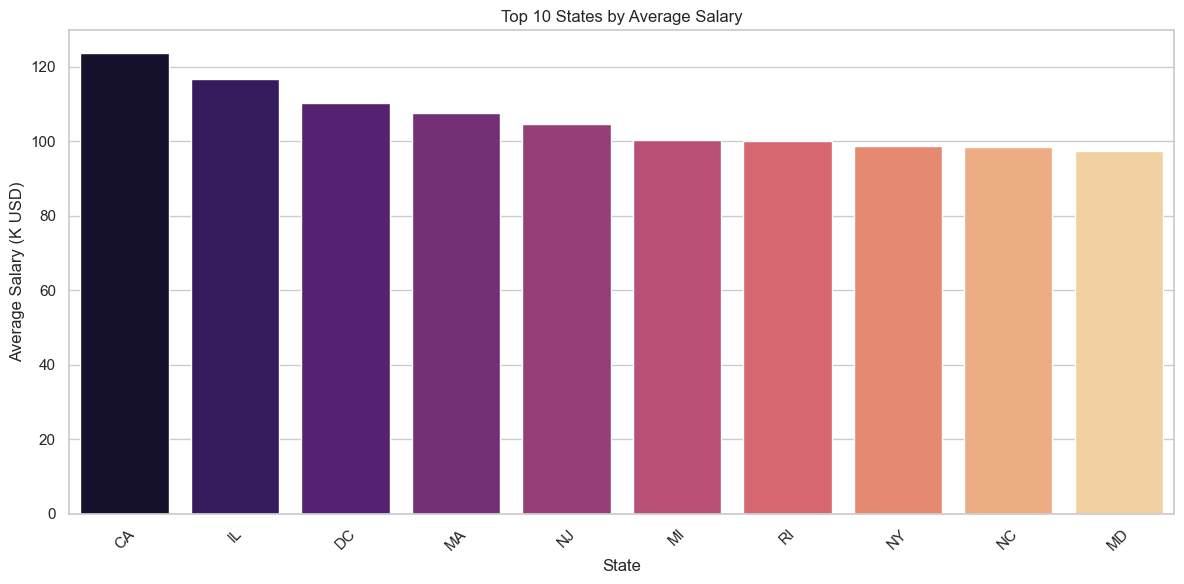

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(data=avg_salary_state.head(10), x="State", y="Avg_Salary_K", palette="magma")
plt.title("Top 10 States by Average Salary")
plt.ylabel("Average Salary (K USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/avg_salary_by_state.png")
plt.show()

## Top 5 industries

In [25]:
top_5_industries = df["Industry"].value_counts().head(5).reset_index()
top_5_industries.columns = ["Industry", "Job_Count"]
top_5_industries

,Industry,Job_Count
0,Biotech & Pharmaceuticals,122
1,Insurance Carriers,63
2,Computer Hardware & Software,59
3,IT Services,50
4,Health Care Services & Hospitals,49


## Chart

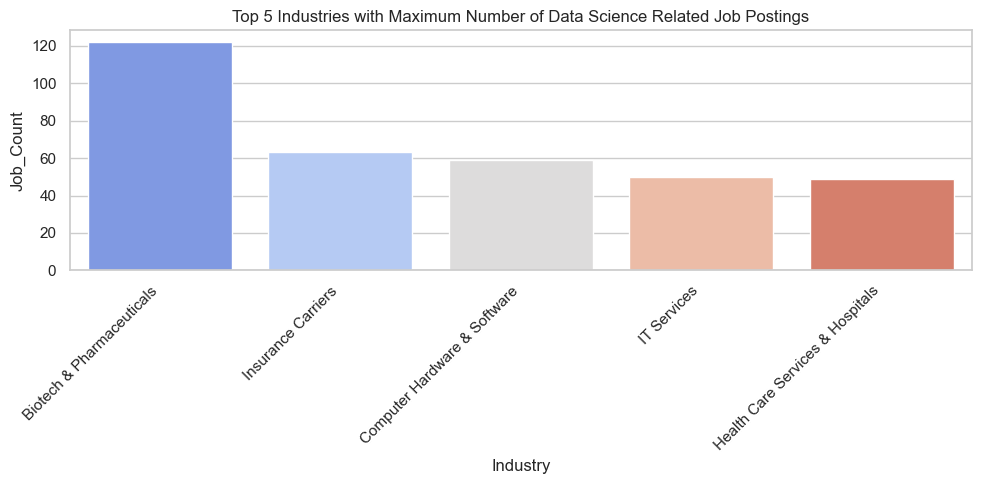

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_5_industries, x="Industry", y="Job_Count", palette="coolwarm")
plt.title("Top 5 Industries with Maximum Number of Data Science Related Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/top_5_industries.png")
plt.show()

## Companies with max openings

In [27]:
companies_max_openings = df["Company_Name"].value_counts().reset_index()
companies_max_openings.columns = ["Company_Name", "Job_Count"]
companies_max_openings.head(10)

,Company_Name,Job_Count
0,MassMutual,14
1,Reynolds American,14
2,Takeda Pharmaceuticals,14
3,Software Engineering Institute,11
4,PNNL,10
5,Liberty Mutual Insurance,10
6,AstraZeneca,9
7,MITRE,8
8,"Numeric, LLC",7
9,Advanced BioScience Laboratories,7


## Chart

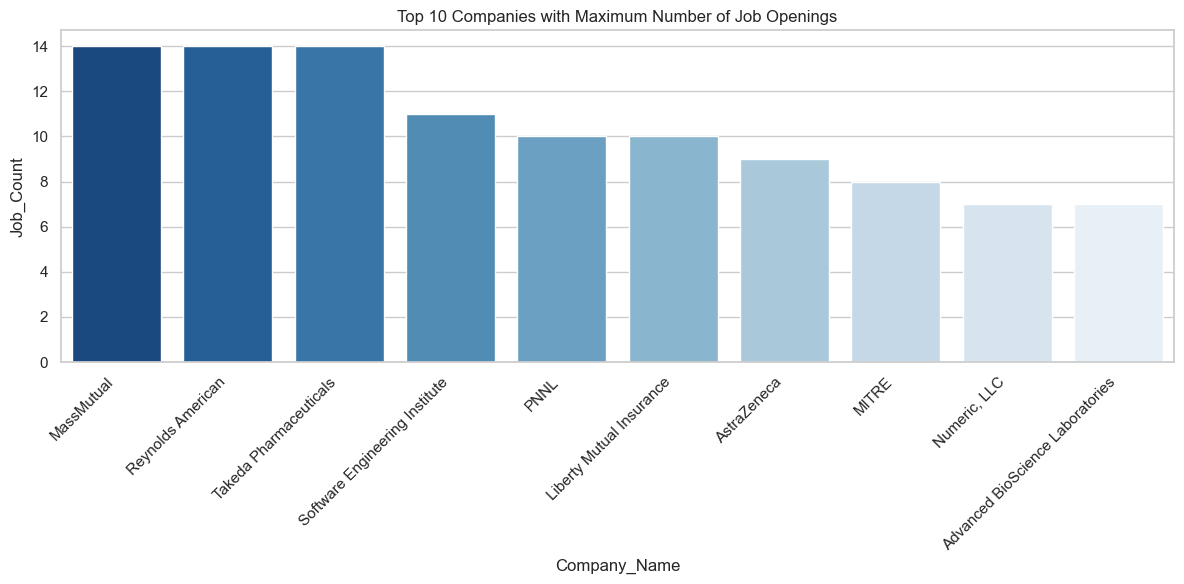

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(data=companies_max_openings.head(10), x="Company_Name", y="Job_Count", palette="Blues_r")
plt.title("Top 10 Companies with Maximum Number of Job Openings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/companies_with_max_openings.png")
plt.show()

## Job titles with most jobs

In [29]:
job_title_col = "Jobtitle_sim" if "Jobtitle_sim" in df.columns else "Job_Title"

job_titles_most_jobs = df[job_title_col].value_counts().reset_index()
job_titles_most_jobs.columns = ["Job_Title", "Job_Count"]
job_titles_most_jobs.head(10)

,Job_Title,Job_Count
0,Data Scientist,131
1,Data Engineer,53
2,Senior Data Scientist,34
3,Data Analyst,15
4,Senior Data Engineer,14
5,Senior Data Analyst,12
6,Lead Data Scientist,8
7,Marketing Data Analyst,6
8,Sr. Data Engineer,6
9,Machine Learning Engineer,5


## Chart

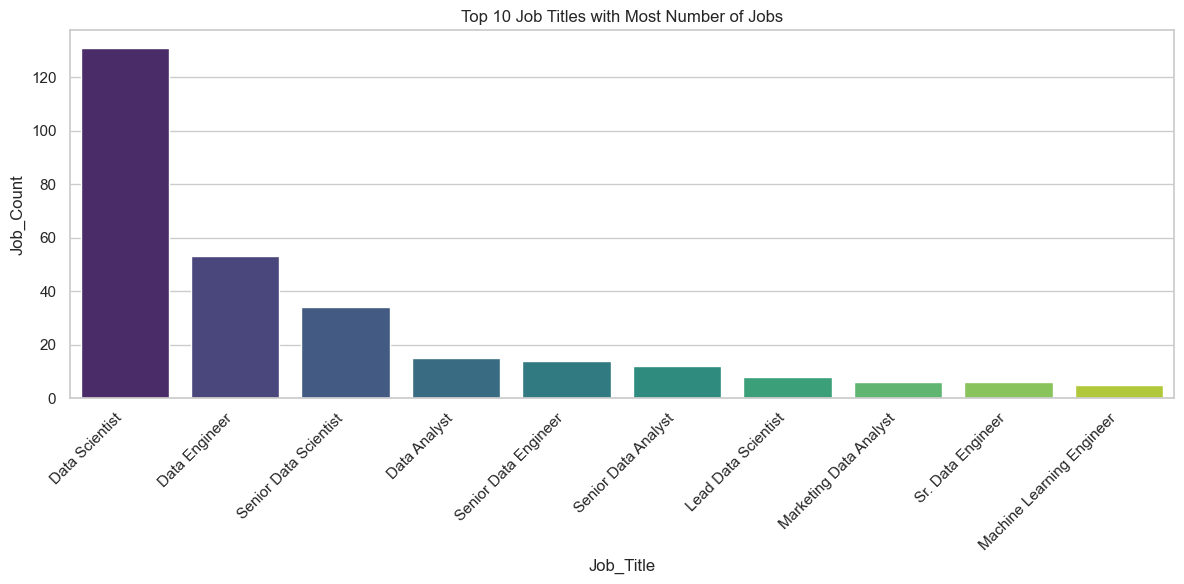

In [30]:
plt.figure(figsize=(12,6))
sns.barplot(data=job_titles_most_jobs.head(10), x="Job_Title", y="Job_Count", palette="viridis")
plt.title("Top 10 Job Titles with Most Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/job_titles_with_most_jobs.png")
plt.show()

## Salary of job titles

In [31]:
salary_job_titles = df.groupby(job_title_col)["Avg_Salary_K"].mean().reset_index()
salary_job_titles.columns = ["Job_Title", "Avg_Salary_K"]
salary_job_titles = salary_job_titles.sort_values(by="Avg_Salary_K", ascending=False)
salary_job_titles

,Job_Title,Avg_Salary_K
94,"Director II, Data Science - GRM Actuarial",254.0
145,Principal Machine Learning Scientist,232.5
144,Principal Data Scientist with over 10 years ex...,225.0
117,Lead Data Engineer,205.0
95,"Director II, Data Science - GRS Predictive Ana...",194.5
...,...,...
136,Medical Technologist / Clinical Laboratory Sci...,41.5
48,Data Analytics Manager,40.5
156,Project Scientist,39.5
6,Associate Data Analyst,38.5


## Chart

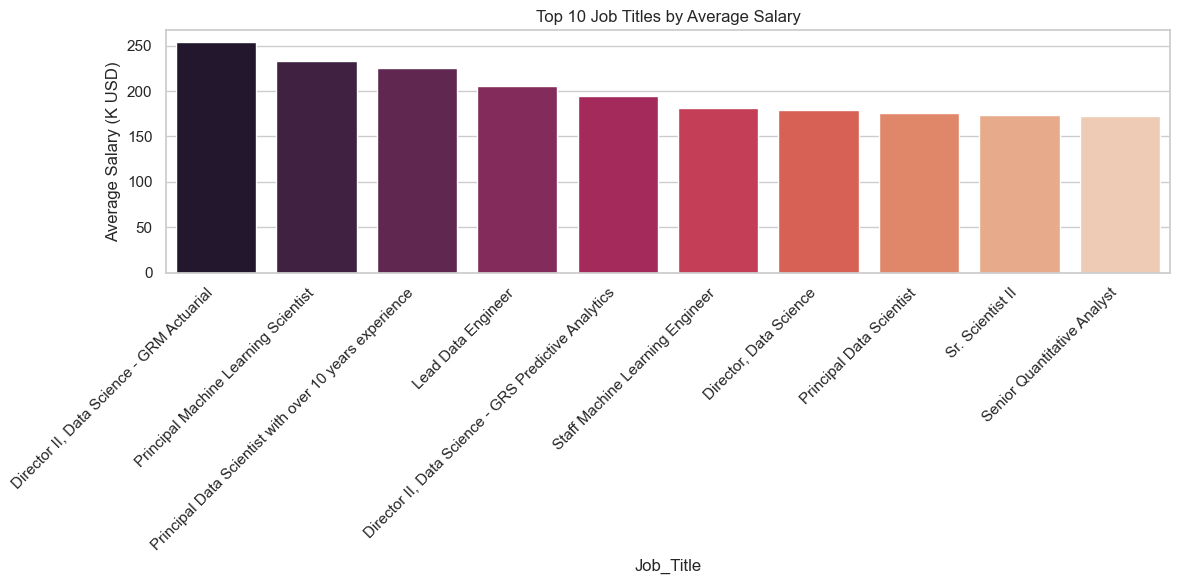

In [32]:
plt.figure(figsize=(12,6))
sns.barplot(data=salary_job_titles.head(10), x="Job_Title", y="Avg_Salary_K", palette="rocket")
plt.title("Top 10 Job Titles by Average Salary")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Salary (K USD)")
plt.tight_layout()
plt.savefig("outputs/charts/salary_of_job_titles.png")
plt.show()

## Skills columns

In [33]:
possible_skills = [
    "python", "spark", "aws", "excel", "sql", "sas", "keras",
    "pytorch", "scikit", "tensor", "hadoop", "tableau",
    "bi", "flink", "mongo", "google_an"
]

skill_cols = [col for col in df.columns if col.lower() in possible_skills]
print("Skill columns found:", skill_cols)

Skill columns found: ['Python', 'spark', 'aws', 'excel', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an']


## Skills by job title

In [34]:
skills_by_job_title = df.groupby(job_title_col)[skill_cols].sum().reset_index()
skills_by_job_title

,Job_Title,Python,spark,aws,excel,sas,keras,pytorch,scikit,tensor,hadoop,tableau,bi,flink,mongo,google_an
0,Ag Data Scientist,b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00'
1,Analytics - Business Assurance Data Analyst,b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00'
2,Analytics Consultant,b'\x01',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x01',b'\x00',b'\x00',b'\x00',b'\x00'
3,Analytics Manager,b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00'
4,Analytics Manager - Data Mart,b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x01\x01\x01\x01',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00',b'\x00\x00\x00\x00'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,Systems Engineer II - Data Analyst,b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00'
260,"Technology-Minded, Data Professional Opportuni...",b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00'
261,"VP, Data Science",b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x01\x01',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00',b'\x00\x00'
262,Web Data Analyst,b'\x01',b'\x00',b'\x00',b'\x01',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x00',b'\x01',b'\x01',b'\x00',b'\x00',b'\x00'


## Skills heatmap

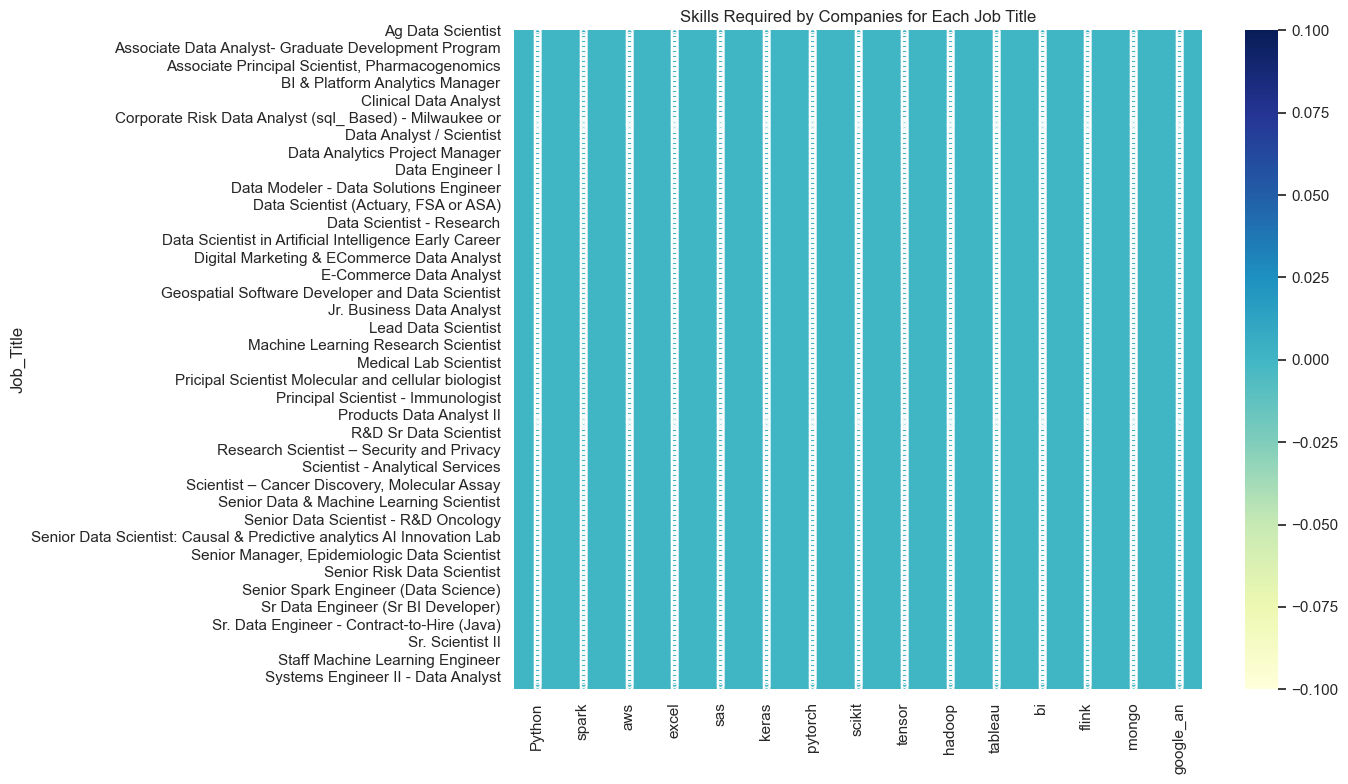

In [35]:
# Make sure skill columns are numeric
for col in skill_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Recreate skills_by_job_title
skills_by_job_title = df.groupby(job_title_col)[skill_cols].sum().reset_index()

# Set index for heatmap
skills_heatmap_data = skills_by_job_title.set_index(job_title_col)

# Convert all values to numeric just to be safe
skills_heatmap_data = skills_heatmap_data.apply(pd.to_numeric, errors="coerce").fillna(0)

plt.figure(figsize=(14,8))
sns.heatmap(skills_heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Skills Required by Companies for Each Job Title")
plt.tight_layout()
plt.savefig("outputs/charts/skills_required_by_job_title_heatmap.png")
plt.show()

## Overall skills

In [36]:
overall_skills = df[skill_cols].sum().sort_values(ascending=False).reset_index()
overall_skills.columns = ["Skill", "Count"]
overall_skills

,Skill,Count
0,Python,0.0
1,spark,0.0
2,aws,0.0
3,excel,0.0
4,sas,0.0
5,keras,0.0
6,pytorch,0.0
7,scikit,0.0
8,tensor,0.0
9,hadoop,0.0


## Chart

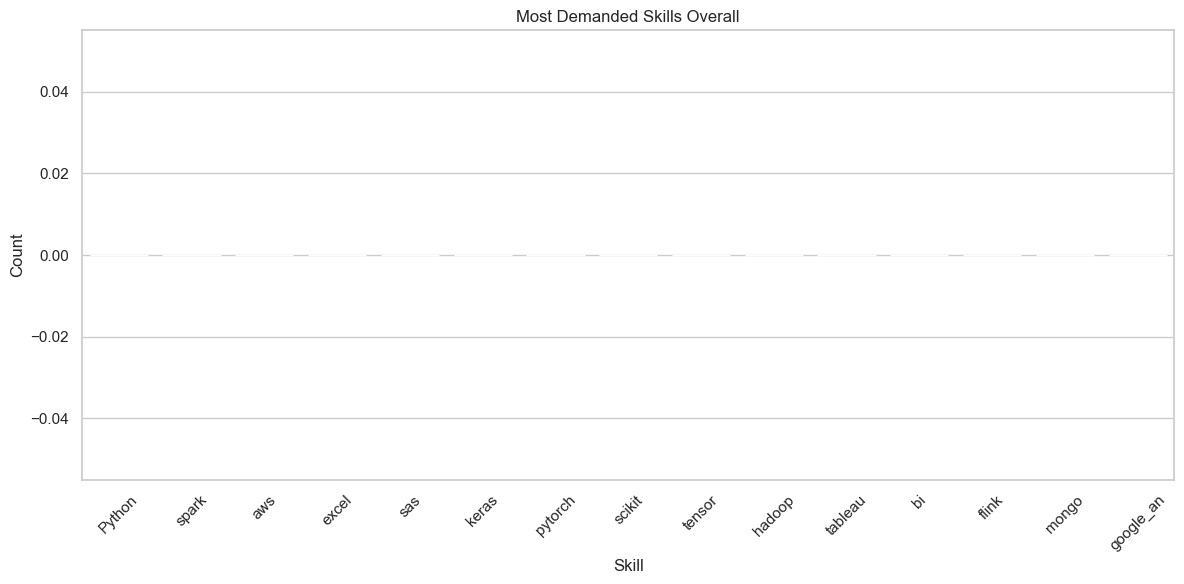

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(data=overall_skills, x="Skill", y="Count", palette="Set2")
plt.title("Most Demanded Skills Overall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/most_demanded_skills_overall.png")
plt.show()

## Salary vs education

In [38]:
if "Degree" in df.columns:
    salary_vs_education = df.groupby("Degree")["Avg_Salary_K"].mean().reset_index()
    salary_vs_education = salary_vs_education.sort_values(by="Avg_Salary_K", ascending=False)
    salary_vs_education
else:
    print("Degree column not found.")

## Chart

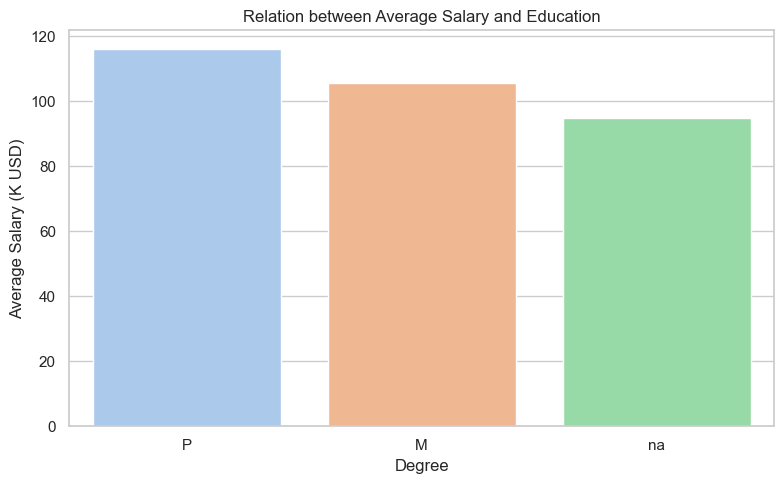

In [39]:
if "Degree" in df.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(data=salary_vs_education, x="Degree", y="Avg_Salary_K", palette="pastel")
    plt.title("Relation between Average Salary and Education")
    plt.ylabel("Average Salary (K USD)")
    plt.tight_layout()
    plt.savefig("outputs/charts/salary_vs_education.png")
    plt.show()

## Extra analysis: correlation heatmap

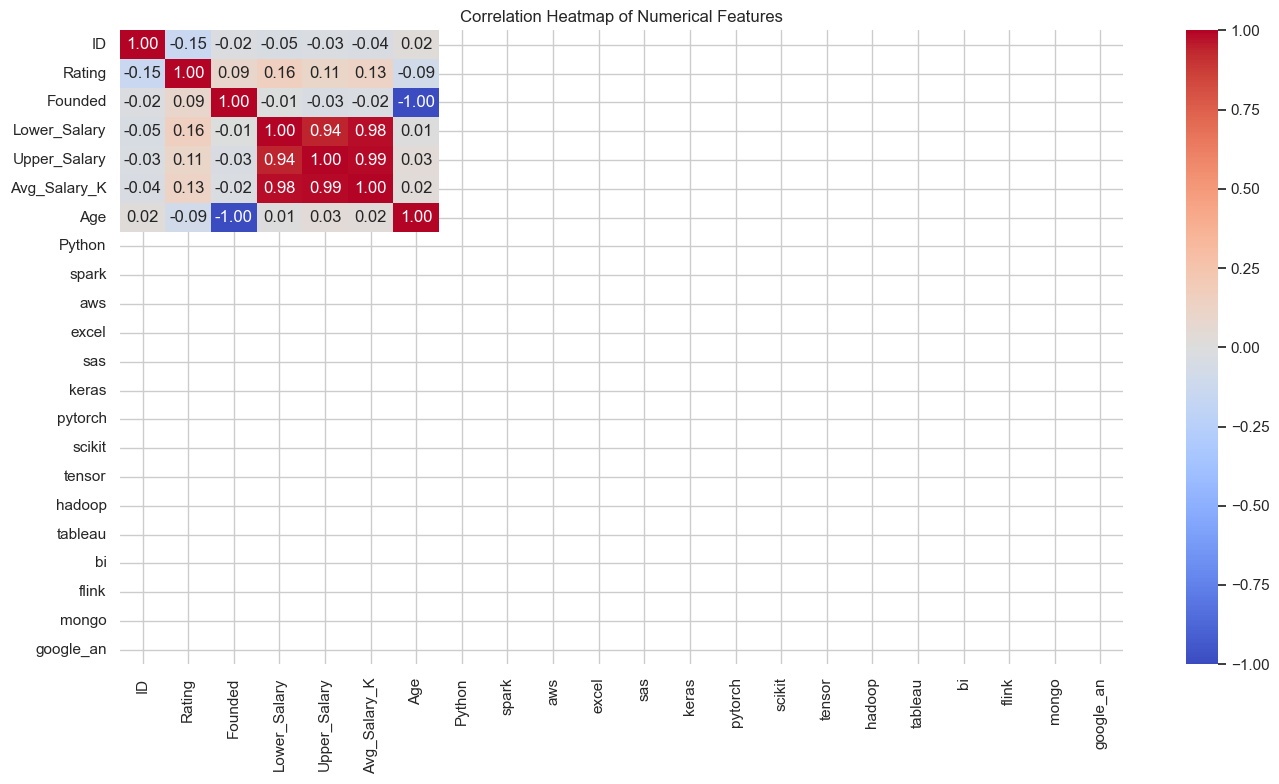

In [40]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("outputs/charts/correlation_heatmap.png")
plt.show()

## Export all tables

In [41]:
states_jobs.to_csv("outputs/tables/states_with_most_jobs.csv", index=False)
avg_min_max_salary_state.to_csv("outputs/tables/avg_min_max_salary_by_state.csv", index=False)
avg_salary_state.to_csv("outputs/tables/avg_salary_by_state.csv", index=False)
top_5_industries.to_csv("outputs/tables/top_5_industries.csv", index=False)
companies_max_openings.to_csv("outputs/tables/companies_with_max_openings.csv", index=False)
job_titles_most_jobs.to_csv("outputs/tables/job_titles_with_most_jobs.csv", index=False)
salary_job_titles.to_csv("outputs/tables/salary_of_job_titles.csv", index=False)
skills_by_job_title.to_csv("outputs/tables/skills_required_by_job_title.csv", index=False)
overall_skills.to_csv("outputs/tables/overall_skills.csv", index=False)

if "Degree" in df.columns:
    salary_vs_education.to_csv("outputs/tables/salary_vs_education.csv", index=False)

print("All tables exported successfully.")

All tables exported successfully.


## KPI summary

In [42]:
summary = pd.DataFrame({
    "Metric": [
        "Total Jobs",
        "Total Companies",
        "Total Industries",
        "Average Salary (K USD)"
    ],
    "Value": [
        len(df),
        df["Company_Name"].nunique() if "Company_Name" in df.columns else np.nan,
        df["Industry"].nunique() if "Industry" in df.columns else np.nan,
        round(df["Avg_Salary_K"].mean(), 2) if "Avg_Salary_K" in df.columns else np.nan
    ]
})

summary

,Metric,Value
0,Total Jobs,742.00
1,Total Companies,343.00
2,Total Industries,59.00
3,Average Salary (K USD),101.48


## Export KPI

In [43]:
summary.to_csv("outputs/tables/summary_kpi.csv", index=False)
print("Summary KPI exported.")

Summary KPI exported.


## Generate report

In [44]:
insights_text = f"""
PRDA – 04 Job Market Analysis
Internship Project Report

1. States with Most Number of Jobs
The analysis shows that data science related job postings are concentrated in a few states.

Top 5 States:
{states_jobs.head(5).to_string(index=False)}

2. Average Minimal and Maximal Salaries in Different States
Salary ranges vary significantly by state.

Top 5 States by Lower Salary:
{avg_min_max_salary_state.head(5).to_string(index=False)}

3. Average Salary in Different States
Some states offer higher average salaries than others.

Top 5 States by Average Salary:
{avg_salary_state.head(5).to_string(index=False)}

4. Top 5 Industries with Maximum Number of Data Science Related Job Postings
{top_5_industries.to_string(index=False)}

5. Companies with Maximum Number of Job Openings
{companies_max_openings.head(10).to_string(index=False)}

6. Job Titles with Most Number of Jobs
{job_titles_most_jobs.head(10).to_string(index=False)}

7. Salary of Job Titles with Most Number of Jobs
{salary_job_titles.head(10).to_string(index=False)}

8. Skills Required by Companies for Each Job Title
Most demanded skills overall:
{overall_skills.to_string(index=False)}
"""

if "Degree" in df.columns:
    insights_text += f"""

9. Relation between Average Salary and Education
{salary_vs_education.to_string(index=False)}
"""

insights_text += """

10. Suggestions to Company
- Focus on hiring in states with more opportunities and high salary competitiveness.
- Prioritize Python, SQL, AWS, Spark, and Tableau skills.
- Benchmark salaries by state and job title.
- Encourage employee upskilling.
- Use clear job descriptions to attract better candidates.

11. Conclusion
This project analyzes job market trends, skill demand, salary patterns, industries, and companies to provide insights useful for both employers and job seekers.
"""

with open("outputs/reports/insights_report.txt", "w", encoding="utf-8") as f:
    f.write(insights_text)

print("Insights report generated successfully.")

Insights report generated successfully.


## View report

In [45]:
print(insights_text)


PRDA – 04 Job Market Analysis
Internship Project Report

1. States with Most Number of Jobs
The analysis shows that data science related job postings are concentrated in a few states.

Top 5 States:
State  Job_Count
   CA        152
   MA        103
   NY         72
   VA         41
   IL         40

2. Average Minimal and Maximal Salaries in Different States
Salary ranges vary significantly by state.

Top 5 States by Lower Salary:
State  Lower_Salary  Upper_Salary
   CA     92.427632    154.598684
   DC     88.636364    131.727273
   IL     88.350000    144.975000
   MA     78.689320    136.300971
   MI     77.000000    123.500000

3. Average Salary in Different States
Some states offer higher average salaries than others.

Top 5 States by Average Salary:
State  Avg_Salary_K
   CA    123.513158
   IL    116.662500
   DC    110.181818
   MA    107.495146
   NJ    104.558824

4. Top 5 Industries with Maximum Number of Data Science Related Job Postings
                        Industry  

## Export final dataset for Power BI

In [46]:
df.to_csv("outputs/tables/final_cleaned_dataset_for_powerbi_tableau.csv", index=False)
print("Final dataset exported for Tableau / Power BI.")

Final dataset exported for Tableau / Power BI.


## Final message

In [47]:
print("Project completed successfully.")
print("Check data and outputs folders for all files.")

Project completed successfully.
Check data and outputs folders for all files.


In [48]:
content = """__pycache__/
.ipynb_checkpoints/
*.pyc
"""

with open(".gitignore", "w") as f:
    f.write(content)

print(".gitignore file created successfully.")

.gitignore file created successfully.
